In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the CSV
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/project_futureInterns/Road Accident Data.xlsx - Data.csv')
df.head()

,Accident_Index,Accident Date,Day_of_Week,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Carriageway_Hazards,...,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,BS0000001,1/1/2021,Thursday,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,One way street,30,15:11,Urban,Fine no high winds,Car
1,BS0000002,1/5/2021,Monday,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,Kensington and Chelsea,NaN,...,11,2,Metropolitan Police,Wet or damp,Single carriageway,30,10:59,Urban,Fine no high winds,Taxi/Private hire car
2,BS0000003,1/4/2021,Sunday,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,Single carriageway,30,14:19,Urban,Fine no high winds,Taxi/Private hire car
3,BS0000004,1/5/2021,Monday,Auto traffic signal,T or staggered junction,Serious,51.507804,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Frost or ice,Single carriageway,30,8:10,Urban,Other,Motorcycle over 500cc
4,BS0000005,1/6/2021,Tuesday,Auto traffic signal,Crossroads,Serious,51.482076,Darkness - lights lit,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,Single carriageway,30,17:25,Urban,Fine no high winds,Car


In [ ]:
# Overview of the dataset
print("Shape of dataset:", df.shape)
df.info()

Shape of dataset: (307973, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Accident_Index              307973 non-null  object 
 1   Accident Date               307973 non-null  object 
 2   Day_of_Week                 307973 non-null  object 
 3   Junction_Control            307973 non-null  object 
 4   Junction_Detail             307973 non-null  object 
 5   Accident_Severity           307973 non-null  object 
 6   Latitude                    307973 non-null  float64
 7   Light_Conditions            307973 non-null  object 
 8   Local_Authority_(District)  307973 non-null  object 
 9   Carriageway_Hazards         5424 non-null    object 
 10  Longitude                   307973 non-null  float64
 11  Number_of_Casualties        307973 non-null  int64  
 12  Number_of_Vehicles          307973 non-nu

In [ ]:
# Check for missing values
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

,0
Carriageway_Hazards,302549
Time,17


In [ ]:
# Summary for numeric columns
df.describe()

,Latitude,Longitude,Number_of_Casualties,Number_of_Vehicles,Speed_limit
count,307973.000000,307973.000000,307973.000000,307973.000000,307973.000000
mean,52.487005,-1.368884,1.356882,1.829063,38.866037
std,1.339011,1.356092,0.815857,0.710477,14.032933
min,49.914488,-7.516225,1.000000,1.000000,10.000000
25%,51.485248,-2.247937,1.000000,1.000000,30.000000
50%,52.225943,-1.349258,1.000000,2.000000,30.000000
75%,53.415517,-0.206810,1.000000,2.000000,50.000000
max,60.598055,1.759398,48.000000,32.000000,70.000000


In [ ]:
# Count of unique values per column
df.nunique().sort_values()

,0
Urban_or_Rural_Area,2
Accident_Severity,4
Road_Type,5
Light_Conditions,5
Road_Surface_Conditions,5
Carriageway_Hazards,5
Day_of_Week,7
Junction_Control,7
Speed_limit,8
Weather_Conditions,8


In [ ]:
# Check existing unique values
print("Before cleaning:", df['Accident_Severity'].unique())

# Replace the misspelled entry
df['Accident_Severity'] = df['Accident_Severity'].replace('Fetal', 'Fatal')

# Confirm the correction
print("After cleaning:", df['Accident_Severity'].unique())

Before cleaning: ['Serious' 'Slight' 'Fetal' 'Fatal']
After cleaning: ['Serious' 'Slight' 'Fatal']


In [ ]:
# Convert 'Accident Date' and 'Time' to datetime
df['Accident Date'] = pd.to_datetime(df['Accident Date'], errors='coerce')
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt.hour

# Extract year, month, day of week
df['Year'] = df['Accident Date'].dt.year
df['Month'] = df['Accident Date'].dt.month
df['Weekday'] = df['Accident Date'].dt.day_name()

# Standardize column names for easier access
df.columns = df.columns.str.replace('[()\-]', '', regex=True).str.replace(' ', '_')

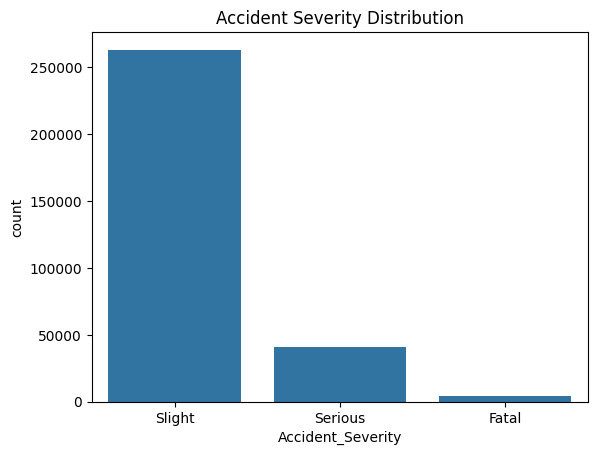

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Accident Severity Distribution
sns.countplot(data=df, x='Accident_Severity', order=df['Accident_Severity'].value_counts().index)
plt.title("Accident Severity Distribution")
plt.show()

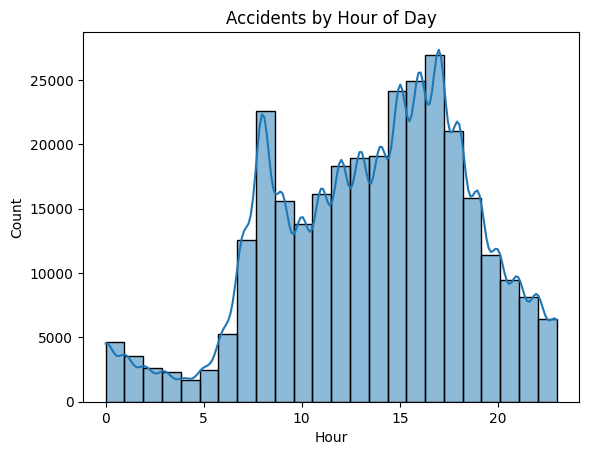

In [ ]:
# Accidents by Hour
sns.histplot(data=df, x='Hour', bins=24, kde=True)
plt.title("Accidents by Hour of Day")
plt.show()

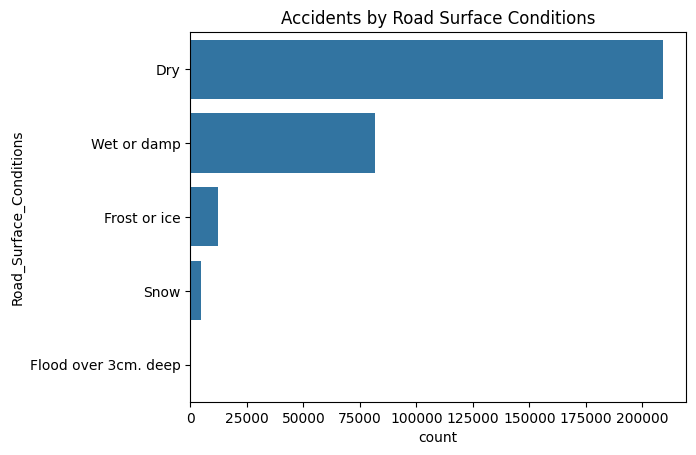

In [ ]:
# Accidents by Road Surface Conditions
sns.countplot(data=df, y='Road_Surface_Conditions', order=df['Road_Surface_Conditions'].value_counts().index)
plt.title("Accidents by Road Surface Conditions")
plt.show()

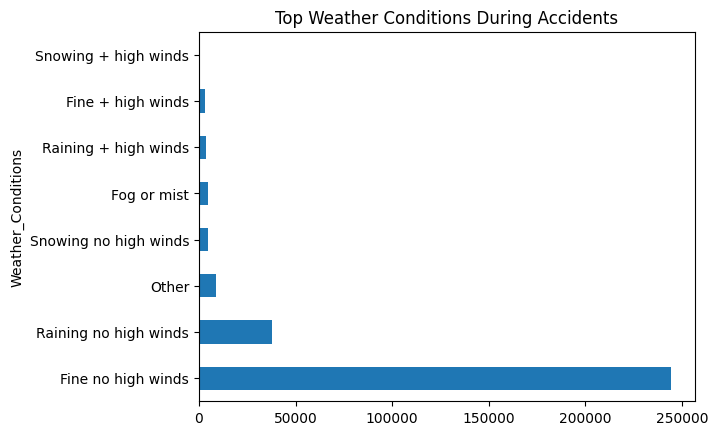

In [ ]:
# Top 10 weather conditions
df['Weather_Conditions'].value_counts().head(10).plot(kind='barh')
plt.title("Top Weather Conditions During Accidents")
plt.show()

In [ ]:
# Cross tab: Severity vs Light Conditions
pd.crosstab(df['Accident_Severity'], df['Light_Conditions'], normalize='index') * 100

Light_Conditions,Darkness - lighting unknown,Darkness - lights lit,Darkness - lights unlit,Darkness - no lighting,Daylight
Accident_Severity,,,,,
Fatal,0.708323,21.806223,0.379459,16.417910,60.688085
Serious,0.876289,20.900835,0.358370,7.555228,70.309278
Slight,0.964373,19.263142,0.372607,4.862124,74.537754


In [ ]:
import folium
from folium.plugins import HeatMap

# Subset of points for performance
subset = df[['Latitude', 'Longitude']].dropna().sample(1000)

# Create map
m = folium.Map(location=[subset.Latitude.mean(), subset.Longitude.mean()], zoom_start=12)
HeatMap(data=subset[['Latitude', 'Longitude']]).add_to(m)
m

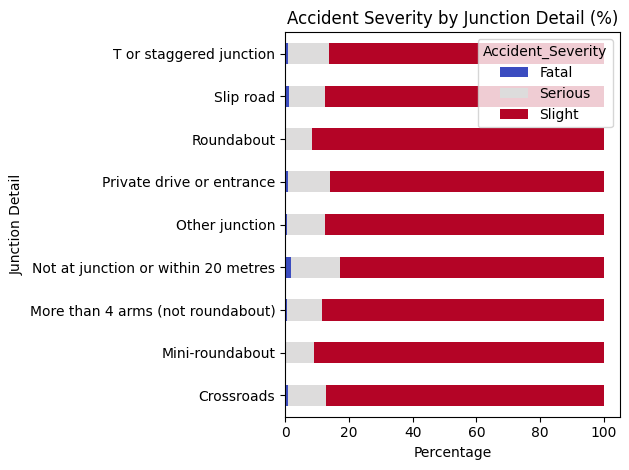

In [ ]:
# --- Severity by Junction Detail ---
junction_detail = pd.crosstab(df['Junction_Detail'], df['Accident_Severity'], normalize='index') * 100
junction_detail.plot(kind='barh', stacked=True, colormap='coolwarm')
plt.title("Accident Severity by Junction Detail (%)")
plt.xlabel("Percentage")
plt.ylabel("Junction Detail")
plt.tight_layout()
plt.show()

<ipython-input-16-f43d058515df>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Accident_Severity', y='Number_of_Vehicles', palette='pastel')


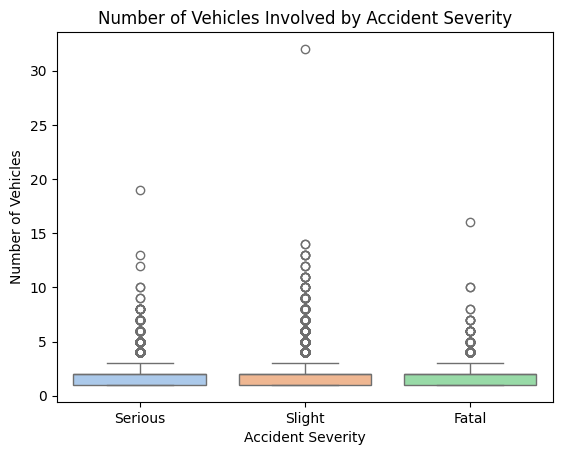

In [ ]:
# --- Severity vs Number of Vehicles ---
sns.boxplot(data=df, x='Accident_Severity', y='Number_of_Vehicles', palette='pastel')
plt.title("Number of Vehicles Involved by Accident Severity")
plt.xlabel("Accident Severity")
plt.ylabel("Number of Vehicles")
plt.show()

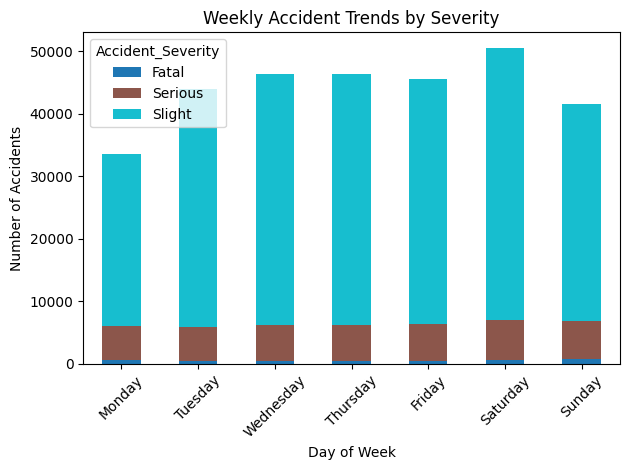

In [ ]:
# --- Weekly Accident Trends by Severity ---
weekly_trend = pd.crosstab(df['Weekday'], df['Accident_Severity'])
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_trend = weekly_trend.reindex(ordered_days)
weekly_trend.plot(kind='bar', stacked=True, colormap='tab10')
plt.title("Weekly Accident Trends by Severity")
plt.xlabel("Day of Week")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

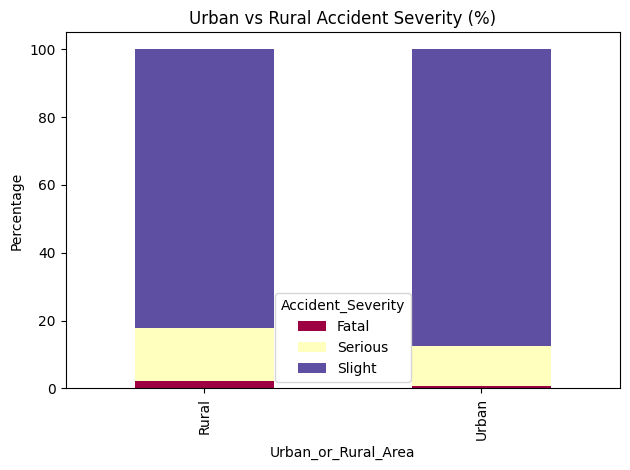

In [ ]:
# --- Urban vs Rural Severity Distribution ---
urban_rural = pd.crosstab(df['Urban_or_Rural_Area'], df['Accident_Severity'], normalize='index') * 100
urban_rural.plot(kind='bar', stacked=True, colormap='Spectral')
plt.title("Urban vs Rural Accident Severity (%)")
plt.ylabel("Percentage")
plt.tight_layout()
plt.show()

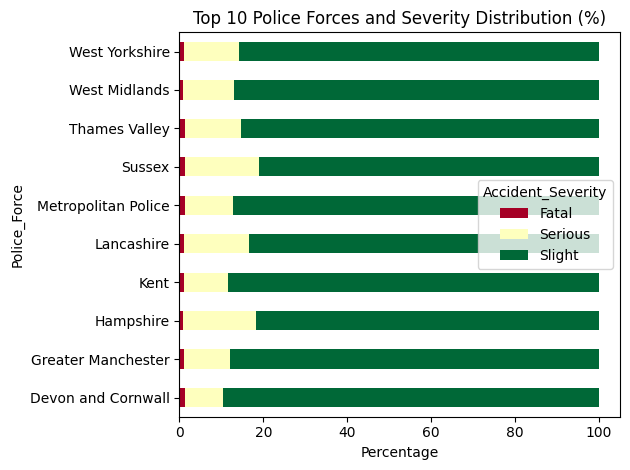

In [ ]:
# --- Police Force vs Severity ---
top_police = df['Police_Force'].value_counts().nlargest(10).index
df_police = df[df['Police_Force'].isin(top_police)]
police_severity = pd.crosstab(df_police['Police_Force'], df_police['Accident_Severity'], normalize='index') * 100
police_severity.plot(kind='barh', stacked=True, colormap='RdYlGn')
plt.title("Top 10 Police Forces and Severity Distribution (%)")
plt.xlabel("Percentage")
plt.tight_layout()
plt.show()

In [ ]:
# --- Map severity to scores for heat mapping / trend scoring ---
severity_map = {'Fatal': 3, 'Serious': 2, 'Slight': 1}
df['Severity_Score'] = df['Accident_Severity'].map(severity_map)

In [ ]:
# --- Accident count and average severity by location (district) ---
location_summary = df.groupby('Local_Authority_District').agg({
    'Accident_Index': 'count',
    'Severity_Score': 'mean',
    'Latitude': 'mean',
    'Longitude': 'mean'
}).rename(columns={'Accident_Index': 'Total_Accidents', 'Severity_Score': 'Avg_Severity'}).reset_index()

In [ ]:
# --- Accident trend by hour ---
hourly_trend = df.groupby('Hour')['Accident_Index'].count().reset_index(name='Accident_Count')

In [ ]:
# --- Trend by weekday ---
weekday_trend = df.groupby('Weekday')['Accident_Index'].count().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
).reset_index(name='Accident_Count')

In [ ]:
# --- Top 10 vehicle types involved in accidents ---
top_vehicles = df['Vehicle_Type'].value_counts().nlargest(10).reset_index()
top_vehicles.columns = ['Vehicle_Type', 'Accident_Count']

In [ ]:
# --- Causes: Weather vs Severity ---
weather_severity = pd.crosstab(df['Weather_Conditions'], df['Accident_Severity'], normalize='index') * 100

In [ ]:
# --- Export summaries for Power BI or additional plots ---
location_summary.to_csv('location_summary.csv', index=False)
hourly_trend.to_csv('hourly_trend.csv', index=False)
weekday_trend.to_csv('weekday_trend.csv', index=False)
top_vehicles.to_csv('top_vehicles.csv', index=False)
weather_severity.to_csv('weather_vs_severity.csv')

In [ ]:
import plotly.express as px

fig_map = px.scatter_mapbox(
    location_summary,
    lat="Latitude",
    lon="Longitude",
    size="Total_Accidents",
    color="Avg_Severity",
    color_continuous_scale="OrRd",
    size_max=25,
    zoom=6,
    hover_name="Local_Authority_District",
    title="Accident Hotspots by District (Bubble Size = Total Accidents, Color = Severity)"
)
fig_map.update_layout(mapbox_style="open-street-map", height=500)
fig_map.show()

In [ ]:
fig_hour = px.line(
    hourly_trend,
    x='Hour',
    y='Accident_Count',
    title="Hourly Trend of Accidents",
    markers=True
)
fig_hour.update_traces(line=dict(color='royalblue'))
fig_hour.show()

In [ ]:
fig_week = px.bar(
    weekday_trend,
    x='Weekday',
    y='Accident_Count',
    title='Accident Frequency by Day of Week',
    color='Accident_Count',
    color_continuous_scale='blues'
)
fig_week.show()

In [ ]:
weather_severity_reset = weather_severity.reset_index()
fig_weather = px.bar(
    weather_severity_reset.melt(id_vars='Weather_Conditions'),
    x='Weather_Conditions',
    y='value',
    color='Accident_Severity',
    barmode='stack',
    title='Severity Distribution by Weather Condition',
    labels={'value': 'Percentage'}
)
fig_weather.show()

In [ ]:
fig_vehicle = px.bar(
    top_vehicles,
    x='Vehicle_Type',
    y='Accident_Count',
    title="Top 10 Vehicle Types Involved in Accidents",
    color='Accident_Count',
    color_continuous_scale='plasma'
)
fig_vehicle.show()

In [ ]:
import plotly.graph_objects as go

fig_table = go.Figure(data=[go.Table(
    header=dict(values=list(location_summary.columns),
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[location_summary[col] for col in location_summary.columns],
               fill_color='lavender',
               align='left'))
])
fig_table.update_layout(title="District-Level Accident Summary")
fig_table.show()